- MNIST est un sous-ensemble d’un ensemble de données plus large provenant du NIST (copié depuis http://yann.lecun.com/exdb/mnist/).
- La base de données MNIST de chiffres manuscrits contient un ensemble d’entraînement de 60 000 exemples.
- Elle contient également un ensemble de test de 10 000 exemples.

![MNIST Dataset](mnist.png)

In [38]:
import tensorflow as tf
from tensorflow import keras

In [39]:
(X_train,y_train),(X_test,y_test) = keras.datasets.mnist.load_data()

In [40]:
X_train.shape

(60000, 28, 28)

<Figure size 640x480 with 0 Axes>

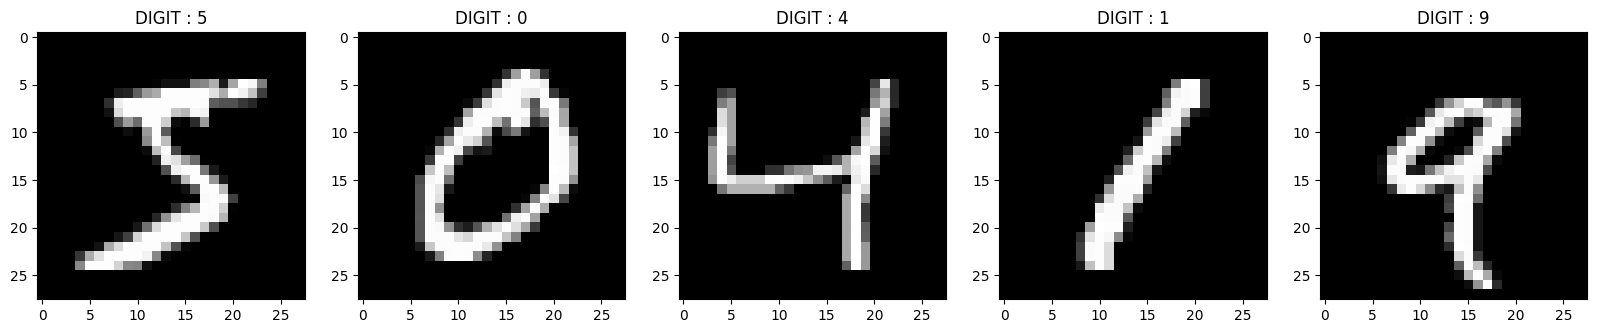

In [41]:
import matplotlib.pyplot as plt
plt.gray()
figure,axis = plt.subplots(ncols = 5 , figsize = (20,20))
for index in range(5):
    axis[index].imshow(X_train[index])
    axis[index].set_title(f"DIGIT : {y_train[index]}")

plt.show()

In [22]:
#X_train_flattened = X_train.reshape(len(X_train), 28*28)

In [30]:
ann = keras.Sequential([
    keras.Input((28,28)),
    keras.layers.Flatten(),
    keras.layers.Dense(100,activation='sigmoid'),
    keras.layers.Dense(10,activation ='sigmoid')
    ])

ann.compile(
    optimizer='adam', 
    loss= 'sparse_categorical_crossentropy', 
    metrics=['accuracy'] 
    )

In [42]:
ann.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)                  │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 100)                 │          78,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │           1,010 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 238,532 (931.77 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 159,022 (621.18 KB)

In [43]:
history1 = ann.fit(X_train, y_train, epochs=10, validation_split=0.3,verbose=1)

Epoch 1/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9200 - loss: 0.2621 - val_accuracy: 0.9215 - val_loss: 0.2656
Epoch 2/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9232 - loss: 0.2525 - val_accuracy: 0.9264 - val_loss: 0.2475
Epoch 3/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9224 - loss: 0.2582 - val_accuracy: 0.9205 - val_loss: 0.2646
Epoch 4/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9271 - loss: 0.2440 - val_accuracy: 0.9214 - val_loss: 0.2619
Epoch 5/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9259 - loss: 0.2473 - val_accuracy: 0.9212 - val_loss: 0.2609
Epoch 6/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9293 - loss: 0.2382 - val_accuracy: 0.9254 - val_loss: 0.2541
Epoch 7/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9308 - loss: 0.2336 - val_accuracy: 0.9295 - val_loss: 0.2340
Epoch 8/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9328 - loss: 0.2266

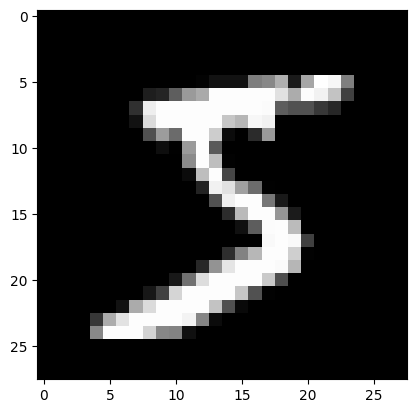

In [44]:
plt.imshow(X_train[0])

In [45]:
predicted_prob  = ann.predict(X_train[0:1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


In [46]:
print([f"{x:.6f}" for x in predicted_prob[0]])

['0.003474', '0.181723', '0.095036', '0.948929', '0.000000', '0.981604', '0.000013', '0.282510', '0.001388', '0.026578']


In [47]:
import numpy as np
predicted_value = np.argmax(predicted_prob, axis=1)

In [48]:
print(predicted_value)

[5]
